In [3]:
%%writefile /kaggle/working/config.py
import torch


PNG_DIR = "/kaggle/input/datasets/hareemzia58/rsna-intracranial-hemorrhage-png-384x384/rsna_dataset_png/rsna_dataset_png"
METADATA_CSV = "/kaggle/input/datasets/hareemzia58/rsna-intracranial-hemorrhage-png-384x384/rsna_metadata.csv"

CHECKPOINT_DIR = "/kaggle/working/checkpoints"
RESULTS_DIR = "/kaggle/working/results"

# ==========================================================
# Data
# ==========================================================

IMG_SIZE = 384

BATCH_SIZE = 16

NUM_WORKERS = 2

PATIENT_ID_COL = "PatientID"

# ==========================================================
# Labels
# ==========================================================

LABEL_COLS = [
    "any",
    "epidural",
    "intraparenchymal",
    "intraventricular",
    "subarachnoid",
    "subdural",
]

NUM_CLASSES = len(LABEL_COLS)

# ==========================================================
# Model
# ==========================================================

MODEL_VARIANT = "efficientnet_b0"

PRETRAINED = True

DROPOUT = 0.3

# ==========================================================
# Optimizer
# ==========================================================

LR = 3e-4

WEIGHT_DECAY = 1e-4

# ==========================================================
# Focal Loss
# ==========================================================

FOCAL_ALPHA = 0.25

FOCAL_GAMMA = 2.0

# ==========================================================
# Training
# ==========================================================

EPOCHS = 50

PATIENCE = 8

USE_AMP = True

SEED = 42

# ==========================================================
# Threshold Search
# ==========================================================

THRESHOLD_MIN = 0.05

THRESHOLD_MAX = 0.95

THRESHOLD_STEP = 0.01

# ==========================================================
# Device
# ==========================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

Overwriting /kaggle/working/config.py


In [5]:
%%writefile /kaggle/working/model.py
import torch.nn as nn
from torchvision import models


_MODEL_REGISTRY = {
    "efficientnet_b0": (
        models.efficientnet_b0,
        models.EfficientNet_B0_Weights.IMAGENET1K_V1,
    )
}


class HemorrhageEfficientNet(nn.Module):

    def __init__(
        self,
        num_classes=6,
        pretrained=True,
        dropout=0.3,
        variant="efficientnet_b0",
    ):

        super().__init__()

        constructor, weights = _MODEL_REGISTRY[variant]

        self.backbone = constructor(
            weights=weights if pretrained else None
        )

        in_features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Sequential(

            nn.Dropout(dropout),

            nn.Linear(
                in_features,
                num_classes,
            ),
        )

    def forward(self, x):

        return self.backbone(x)


def build_model(device=None):

    model = HemorrhageEfficientNet(
        num_classes=6,
        pretrained=True,
        dropout=0.3,
        variant="efficientnet_b0",
    )

    if device is not None:
        model = model.to(device)

    return model

Writing /kaggle/working/model.py


In [7]:
%%writefile /kaggle/working/losses.py
import torch
import torch.nn as nn
import torch.nn.functional as F


class FocalLossWithLogits(nn.Module):

    def __init__(
        self,
        alpha=0.25,
        gamma=2.0,
        reduction="mean"
    ):
        super().__init__()

        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):

        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none"
        )

        probs = torch.sigmoid(logits)

        pt = probs * targets + (1 - probs) * (1 - targets)

        alpha_factor = self.alpha * targets + (1 - self.alpha) * (1 - targets)

        focal_weight = alpha_factor * ((1 - pt) ** self.gamma)

        loss = focal_weight * bce

        if self.reduction == "mean":
            return loss.mean()

        elif self.reduction == "sum":
            return loss.sum()

        return loss

Overwriting /kaggle/working/losses.py


In [8]:
%%writefile /kaggle/working/data_loader.py
import os
import cv2
import torch
import numpy as np
import pandas as pd

from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import StratifiedGroupKFold


def get_train_transforms(img_size=384):

    return A.Compose([

        A.HorizontalFlip(p=0.5),

        A.ShiftScaleRotate(
            shift_limit=0.03,
            scale_limit=0.05,
            rotate_limit=10,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.5,
        ),

        A.GaussNoise(
            std_range=(0.01, 0.03),
            mean_range=(0.0, 0.0),
            p=0.25,
        ),

        A.GaussianBlur(
            blur_limit=(3, 3),
            p=0.15,
        ),

        A.ElasticTransform(
            alpha=1,
            sigma=20,
            p=0.10,
        ),

        A.Resize(img_size, img_size),

        A.Normalize(
            mean=[0.485,0.456,0.406],
            std=[0.229,0.224,0.225]
        ),

        ToTensorV2()

    ])


def get_val_transforms(img_size=384):

    return A.Compose([

        A.Resize(img_size, img_size),

        A.Normalize(
            mean=[0.485,0.456,0.406],
            std=[0.229,0.224,0.225]
        ),

        ToTensorV2()

    ])


class RSNADataset(Dataset):

    def __init__(self, df, img_dir, transform=None):

        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.label_cols = [
            "any",
            "epidural",
            "intraparenchymal",
            "intraventricular",
            "subarachnoid",
            "subdural"
        ]

        self.labels = self.df[self.label_cols].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        image_id = self.df.iloc[idx]["Image_ID"]

        path = os.path.join(
            self.img_dir,
            image_id + ".png"
        )

        image = cv2.imread(path)

        if image is None:
            raise FileNotFoundError(path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform is not None:
            image = self.transform(image=image)["image"]

        label = torch.tensor(
            self.labels[idx],
            dtype=torch.float32
        )

        return image, label


def prepare_dataloaders(
    df,
    img_dir,
    batch_size,
    num_workers,
    img_size,
    patient_col="PatientID",
):

    groups = df[patient_col]
    y = df["any"]

    outer = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    train_idx, temp_idx = next(
        outer.split(df, y, groups)
    )

    train_df = df.iloc[train_idx].reset_index(drop=True)
    temp_df = df.iloc[temp_idx].reset_index(drop=True)

    inner = StratifiedGroupKFold(
        n_splits=2,
        shuffle=True,
        random_state=42
    )

    val_idx, test_idx = next(

        inner.split(

            temp_df,

            temp_df["any"],

            temp_df[patient_col]

        )

    )

    val_df = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)

    print()

    print("Dataset Summary")

    print("--------------------------")

    print("Train :", len(train_df))
    print("Val   :", len(val_df))
    print("Test  :", len(test_df))

    train_dataset = RSNADataset(
        train_df,
        img_dir,
        get_train_transforms(img_size)
    )

    val_dataset = RSNADataset(
        val_df,
        img_dir,
        get_val_transforms(img_size)
    )

    test_dataset = RSNADataset(
        test_df,
        img_dir,
        get_val_transforms(img_size)
    )

    pin = torch.cuda.is_available()

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin,
        persistent_workers=(num_workers > 0),
        prefetch_factor=2 if num_workers > 0 else None,
        drop_last=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
        persistent_workers=(num_workers > 0),
        prefetch_factor=2 if num_workers > 0 else None,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
        persistent_workers=(num_workers > 0),
        prefetch_factor=2 if num_workers > 0 else None,
    )

    return train_loader, val_loader, test_loader

Writing /kaggle/working/data_loader.py


In [10]:
%%writefile /kaggle/working/metrics.py
import numpy as np

from sklearn.metrics import (
    classification_report,
    average_precision_score,
    precision_recall_curve,
    f1_score,
)

LABELS = [
    "any",
    "epidural",
    "intraparenchymal",
    "intraventricular",
    "subarachnoid",
    "subdural",
]


# -------------------------------------------------------
# Apply thresholds
# -------------------------------------------------------

def apply_thresholds(probabilities, thresholds):
    thresholds = np.asarray(thresholds)
    return (probabilities >= thresholds).astype(np.uint8)


# -------------------------------------------------------
# Macro F1
# -------------------------------------------------------

def macro_f1(y_true, y_pred):
    return f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )


# -------------------------------------------------------
# PR-AUC
# -------------------------------------------------------

def compute_pr_auc(y_true, probabilities):

    scores = {}

    for i, label in enumerate(LABELS):

        scores[label] = average_precision_score(
            y_true[:, i],
            probabilities[:, i],
        )

    return scores


# -------------------------------------------------------
# Learn best threshold per class
# -------------------------------------------------------

def find_best_thresholds(y_true, probabilities):

    best_thresholds = []
    best_f1_scores = []

    for i in range(len(LABELS)):

        precision, recall, thresholds = precision_recall_curve(
            y_true[:, i],
            probabilities[:, i],
        )

        # precision_recall_curve returns N+1 precision/recall values
        # but only N thresholds.
        f1 = (
            2 * precision[:-1] * recall[:-1]
        ) / (
            precision[:-1] + recall[:-1] + 1e-12
        )

        best_idx = np.argmax(f1)

        best_thresholds.append(thresholds[best_idx])
        best_f1_scores.append(f1[best_idx])

    return (
        np.array(best_thresholds),
        np.array(best_f1_scores),
    )


# -------------------------------------------------------
# Classification report
# -------------------------------------------------------

def classification_report_from_probs(
    y_true,
    probabilities,
    thresholds,
):

    preds = apply_thresholds(
        probabilities,
        thresholds,
    )

    return classification_report(
        y_true,
        preds,
        target_names=LABELS,
        zero_division=0,
    )


# -------------------------------------------------------
# Complete evaluation
# -------------------------------------------------------

def evaluate(
    y_true,
    probabilities,
):

    # 1. Learn thresholds from validation predictions
    best_thresholds, best_f1 = find_best_thresholds(
        y_true,
        probabilities,
    )

    # 2. Apply learned thresholds
    preds = apply_thresholds(
        probabilities,
        best_thresholds,
    )

    # 3. Compute Macro F1 USING learned thresholds
    macro = macro_f1(
        y_true,
        preds,
    )

    # 4. Classification report
    report = classification_report(
        y_true,
        preds,
        target_names=LABELS,
        zero_division=0,
    )

    # 5. PR-AUC
    pr_auc = compute_pr_auc(
        y_true,
        probabilities,
    )

    return {

        "macro_f1": macro,

        "report": report,

        "pr_auc": pr_auc,

        "best_thresholds": best_thresholds,

        "best_f1": best_f1,

        "predictions": preds,

    }

Overwriting /kaggle/working/metrics.py


In [13]:
%%writefile /kaggle/working/train.py
import os
import random
import numpy as np

import torch
import torch.nn as nn

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

from torch.cuda.amp import autocast, GradScaler

import pandas as pd

from tqdm import tqdm

import config

from model import build_model
from losses import FocalLossWithLogits
from data_loader import prepare_dataloaders
from metrics import evaluate


# -------------------------------------------------------
# Seed
# -------------------------------------------------------

def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(config.SEED)

os.makedirs(config.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(config.RESULTS_DIR, exist_ok=True)


# -------------------------------------------------------
# Data
# -------------------------------------------------------

df = pd.read_csv(config.METADATA_CSV)

train_loader, val_loader, test_loader = prepare_dataloaders(
    df=df,
    img_dir=config.PNG_DIR,
    batch_size=config.BATCH_SIZE,
    num_workers=config.NUM_WORKERS,
    img_size=config.IMG_SIZE,
    patient_col=config.PATIENT_ID_COL,
)


# -------------------------------------------------------
# Model
# -------------------------------------------------------

model = build_model(config.DEVICE)

criterion = FocalLossWithLogits(
    alpha=config.FOCAL_ALPHA,
    gamma=config.FOCAL_GAMMA,
)

optimizer = AdamW(
    model.parameters(),
    lr=config.LR,
    weight_decay=config.WEIGHT_DECAY,
)

scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=5,
    T_mult=2,
)

scaler = GradScaler(enabled=config.USE_AMP)


best_macro_f1 = -1

patience_counter = 0

best_thresholds = None


# -------------------------------------------------------
# Training
# -------------------------------------------------------

for epoch in range(config.EPOCHS):

    print(f"\nEpoch {epoch+1}/{config.EPOCHS}")

    ######################################
    # TRAIN
    ######################################

    model.train()

    running_loss = 0

    train_bar = tqdm(train_loader)

    for batch_idx, (images, labels) in enumerate(train_bar):

        images = images.to(config.DEVICE)

        labels = labels.to(config.DEVICE)

        optimizer.zero_grad()

        with autocast(enabled=config.USE_AMP):

            logits = model(images)

            loss = criterion(logits, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        scheduler.step(
        epoch + batch_idx / len(train_loader)
        )

        running_loss += loss.item()

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss = running_loss / len(train_loader)

    ######################################
    # VALIDATION
    ######################################

    model.eval()

    val_loss = 0

    all_probs = []

    all_labels = []

    with torch.no_grad():

        for images, labels in tqdm(val_loader):

            images = images.to(config.DEVICE)

            labels = labels.to(config.DEVICE)

            with autocast(enabled=config.USE_AMP):

                logits = model(images)

                loss = criterion(logits, labels)

            probs = torch.sigmoid(logits)

            val_loss += loss.item()

            all_probs.append(
                probs.cpu().numpy()
            )

            all_labels.append(
                labels.cpu().numpy()
            )

    val_loss /= len(val_loader)

    all_probs = np.concatenate(all_probs)

    all_labels = np.concatenate(all_labels)

    metrics = evaluate(
        all_labels,
        all_probs,
    )

    macro_f1 = metrics["macro_f1"]

    learned_thresholds = metrics["best_thresholds"]

    learned_f1 = metrics["best_f1"]

    pr_auc = metrics["pr_auc"]

    print()

    print(f"Train Loss : {train_loss:.5f}")

    print(f"Val Loss   : {val_loss:.5f}")

    print(f"Macro F1   : {macro_f1:.4f}")

    print()

    print("Per-class PR-AUC")

    for k, v in pr_auc.items():
        print(f"{k:20s}: {v:.4f}")

    print()

    print("Learned thresholds")

    for name, th, f1 in zip(
        config.LABEL_COLS,
        learned_thresholds,
        learned_f1,
    ):
        print(
            f"{name:20s}"
            f"threshold={th:.3f}"
            f"  bestF1={f1:.3f}"
        )

    ######################################
    # Save best model
    ######################################

    if macro_f1 > best_macro_f1:

        best_macro_f1 = macro_f1

        patience_counter = 0

        best_thresholds = learned_thresholds

        torch.save(

            {
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "thresholds": learned_thresholds,
                "macro_f1": macro_f1,
                "epoch": epoch,
            },

            os.path.join(
                config.CHECKPOINT_DIR,
                "best_model.pth",
            ),
        )

        print("\nSaved new best model.")

    else:

        patience_counter += 1

    if patience_counter >= config.PATIENCE:

        print("\nEarly stopping.")

        break


# -------------------------------------------------------
# Save Thresholds
# -------------------------------------------------------

np.save(

    os.path.join(
        config.RESULTS_DIR,
        "best_thresholds.npy",
    ),

    best_thresholds,

)

print("\nTraining complete.")

print("\nBest Macro F1 =", best_macro_f1)

print("\nBest Thresholds")

for n, t in zip(config.LABEL_COLS, best_thresholds):
    print(f"{n:20s}: {t:.3f}")

Overwriting /kaggle/working/train.py


In [14]:
!python /kaggle/working/train.py


Dataset Summary
--------------------------
Train : 79845
Val   : 10088
Test  : 10069
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|███████████████████████████████████████| 20.5M/20.5M [00:00<00:00, 121MB/s]
/kaggle/working/train.py:86: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=config.USE_AMP)

Epoch 1/50
  0%|                                                  | 0/4990 [00:00<?, ?it/s]/kaggle/working/train.py:122: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` i

### Evaluation on test set


Dataset Summary
--------------------------
Train : 79845
Val   : 10088
Test  : 10069


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


any                 : 0.411
epidural            : 0.411
intraparenchymal    : 0.331
intraventricular    : 0.345
subarachnoid        : 0.364
subdural            : 0.316

Best validation Macro F1: 0.6680
Saved at epoch: 9

Classification Report

                  precision    recall  f1-score   support

             any     0.8793    0.7611    0.8160      1570
        epidural     0.1111    0.0256    0.0417        39
intraparenchymal     0.8020    0.7548    0.7777       526
intraventricular     0.7904    0.7460    0.7675       374
    subarachnoid     0.7283    0.5888    0.6511       569
        subdural     0.6274    0.7091    0.6658       691

       micro avg     0.7802    0.7156    0.7465      3769
       macro avg     0.6564    0.5976    0.6200      3769
    weighted avg     0.7828    0.7156    0.7454      3769
     samples avg     0.1116    0.1096    0.1087      3769



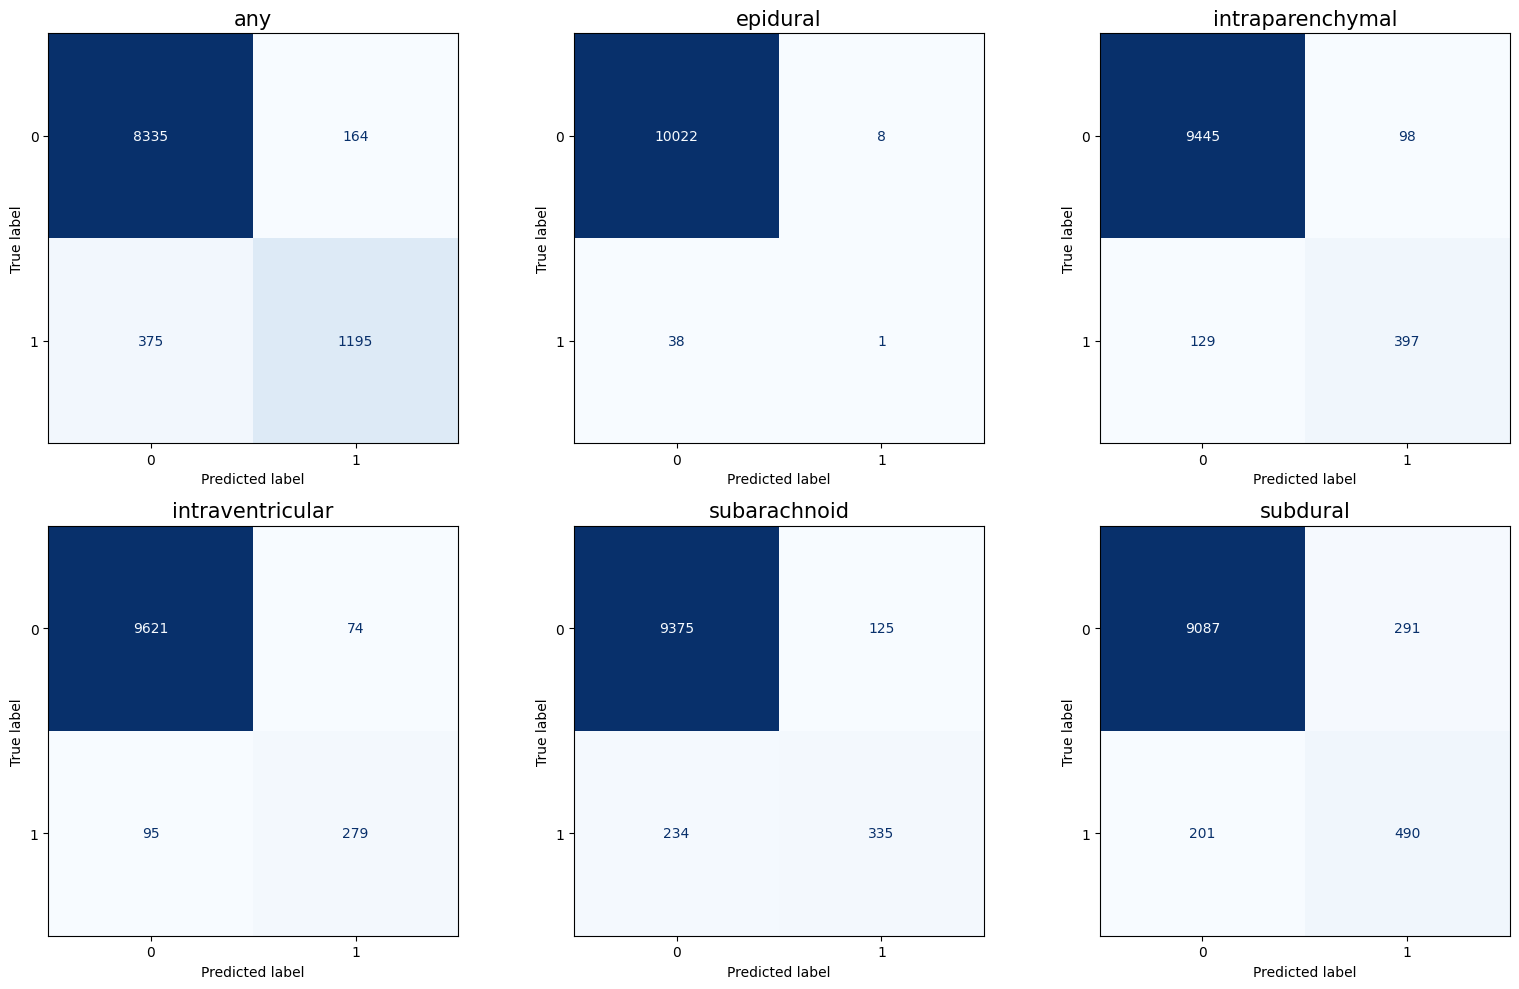

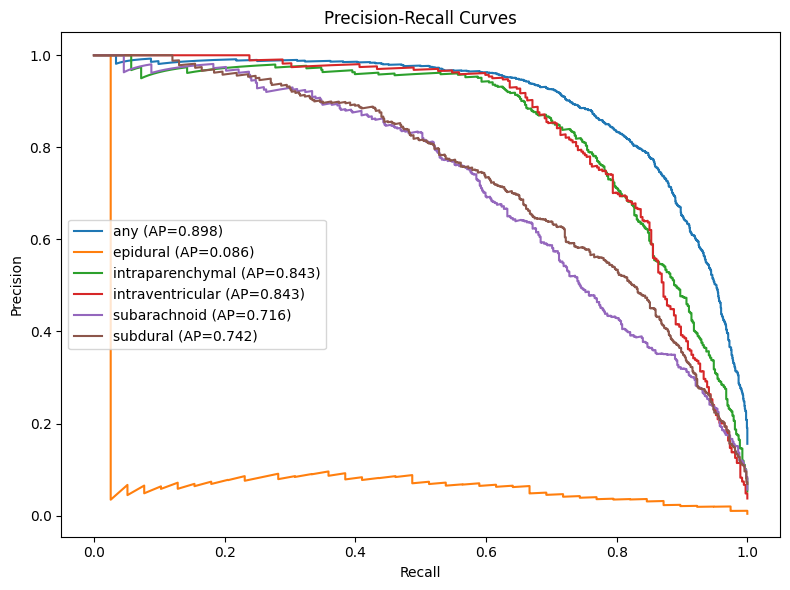

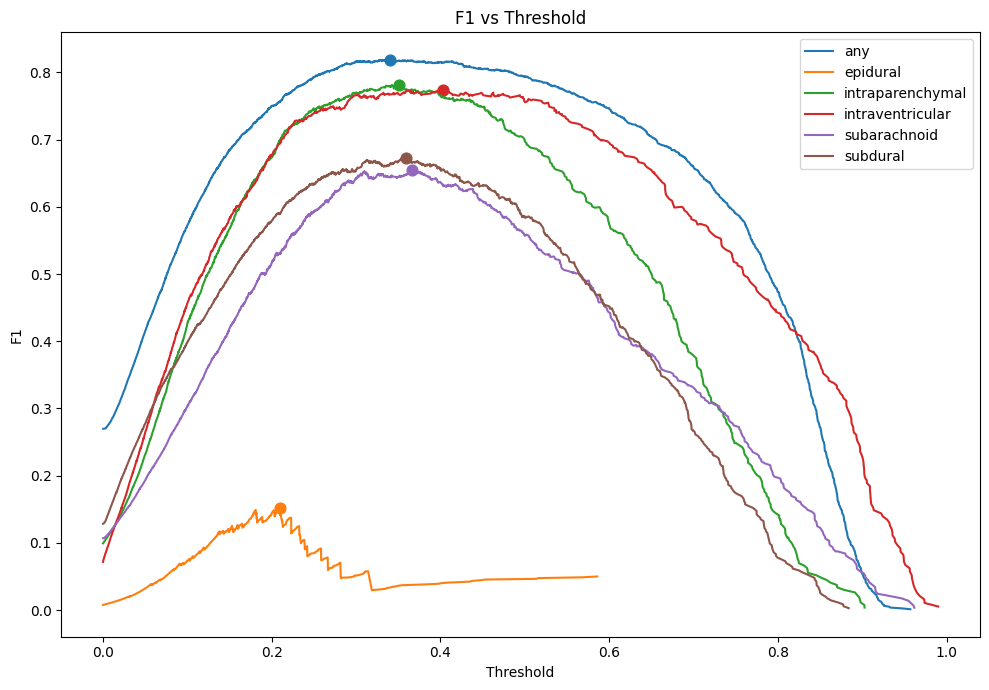


PR-AUC Scores

any                 : 0.8975
epidural            : 0.0857
intraparenchymal    : 0.8426
intraventricular    : 0.8429
subarachnoid        : 0.7160
subdural            : 0.7415


In [4]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    multilabel_confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
)

import config

from model import build_model
from data_loader import prepare_dataloaders

# ---------------------------------------------------------
# Load data
# ---------------------------------------------------------

df = pd.read_csv(config.METADATA_CSV)

_, _, test_loader = prepare_dataloaders(
    df=df,
    img_dir=config.PNG_DIR,
    batch_size=config.BATCH_SIZE,
    num_workers=config.NUM_WORKERS,
    img_size=config.IMG_SIZE,
    patient_col=config.PATIENT_ID_COL,
)

# ---------------------------------------------------------
# Load model
# ---------------------------------------------------------

checkpoint = torch.load(
    os.path.join(
        config.CHECKPOINT_DIR,
        "best_model.pth",
    ),
    map_location=config.DEVICE,
    weights_only=False,   # <-- PyTorch 2.6 fix
)

model = build_model(config.DEVICE)
model.load_state_dict(checkpoint["model"])
model.eval()

# Convert thresholds to numpy array
thresholds = np.asarray(
    checkpoint["thresholds"],
    dtype=np.float32,
)


for name, th in zip(config.LABEL_COLS, thresholds):
    print(f"{name:20s}: {th:.3f}")

print(f"\nBest validation Macro F1: {checkpoint['macro_f1']:.4f}")
print(f"Saved at epoch: {checkpoint['epoch'] + 1}")

# ---------------------------------------------------------
# Predict
# ---------------------------------------------------------

all_probs = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(config.DEVICE)

        logits = model(images)

        probs = torch.sigmoid(logits)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

preds = (all_probs >= thresholds).astype(int)

results_dir = config.RESULTS_DIR
os.makedirs(results_dir, exist_ok=True)

# =========================================================
# 1. Classification Report
# =========================================================

report = classification_report(
    all_labels,
    preds,
    target_names=config.LABEL_COLS,
    digits=4,
    zero_division=0,
)

print("\nClassification Report\n")
print(report)

with open(
    os.path.join(results_dir, "classification_report.txt"),
    "w",
) as f:
    f.write(report)

# =========================================================
# 2. Confusion Matrices
# =========================================================
cms = multilabel_confusion_matrix(
    all_labels,
    preds,
)
fig, axes = plt.subplots(2,3, figsize=(16,10))

axes = axes.flatten()

for i, label in enumerate(config.LABEL_COLS):

    disp = ConfusionMatrixDisplay(confusion_matrix=cms[i])

    disp.plot(
        ax=axes[i],
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    axes[i].set_title(label, fontsize=15)

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "confusion_matrices.png"
    ),
    dpi=300
)

plt.show()

# =========================================================
# 3. Precision-Recall Curves
# =========================================================

plt.figure(figsize=(8,6))

for i, label in enumerate(config.LABEL_COLS):

    precision, recall, _ = precision_recall_curve(
        all_labels[:, i],
        all_probs[:, i],
    )

    ap = average_precision_score(
        all_labels[:, i],
        all_probs[:, i],
    )

    plt.plot(
        recall,
        precision,
        label=f"{label} (AP={ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "precision_recall_curves.png"
    )
)

plt.show()


# =========================================================
# 5. PR-AUC Table
# =========================================================

print("\nPR-AUC Scores\n")

pr_scores = {}

for i, label in enumerate(config.LABEL_COLS):

    ap = average_precision_score(
        all_labels[:, i],
        all_probs[:, i],
    )

    pr_scores[label] = ap

    print(f"{label:20s}: {ap:.4f}")

pd.DataFrame(
    {
        "Class": list(pr_scores.keys()),
        "PR-AUC": list(pr_scores.values()),
        "Threshold": thresholds,
    }
).to_csv(
    os.path.join(
        results_dir,
        "pr_auc_scores.csv"
    ),
    index=False,
)


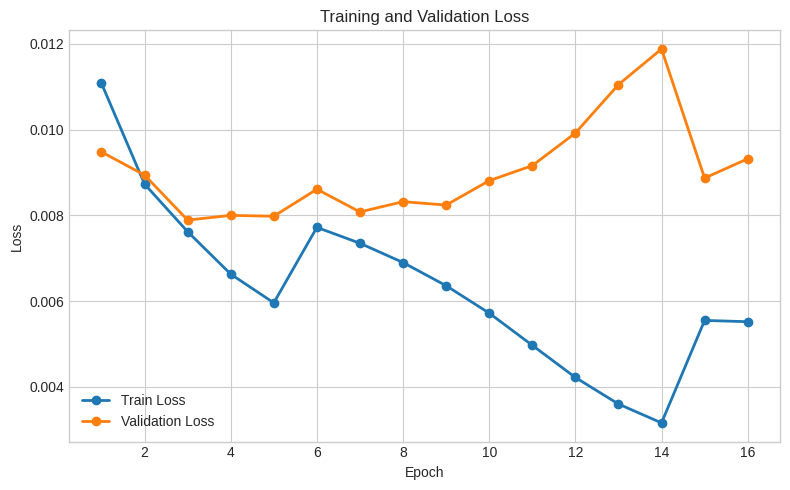

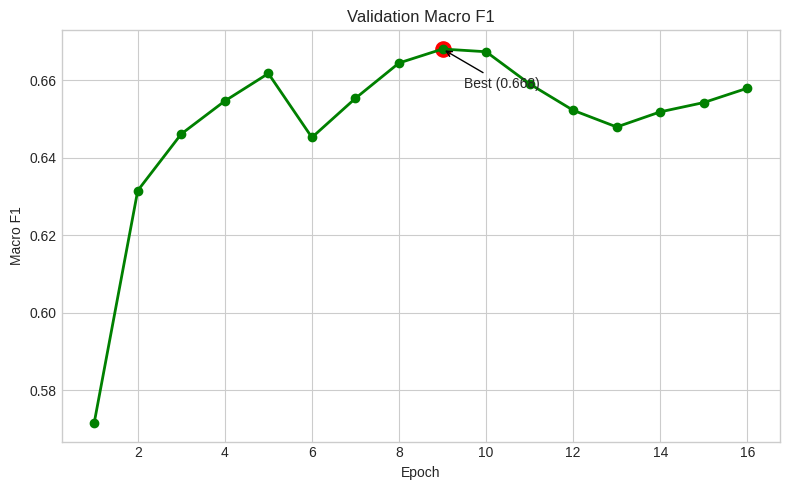

In [7]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1,17)

train_loss = [
0.01108,
0.00873,
0.00762,
0.00663,
0.00596,
0.00772,
0.00735,
0.00690,
0.00636,
0.00572,
0.00497,
0.00422,
0.00360,
0.00316,
0.00555,
0.00552
]

val_loss = [
0.00948,
0.00894,
0.00789,
0.00800,
0.00798,
0.00861,
0.00808,
0.00832,
0.00824,
0.00881,
0.00916,
0.00992,
0.01105,
0.01188,
0.00887,
0.00932
]

macro_f1 = [
0.5716,
0.6315,
0.6461,
0.6546,
0.6617,
0.6452,
0.6553,
0.6644,
0.6680,
0.6673,
0.6590,
0.6522,
0.6479,
0.6518,
0.6542,
0.6579
]

plt.style.use("seaborn-v0_8-whitegrid")

#####################################################
# Loss
#####################################################

plt.figure(figsize=(8,5))

plt.plot(epochs, train_loss, marker='o', linewidth=2, label='Train Loss')
plt.plot(epochs, val_loss, marker='o', linewidth=2, label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()

plt.tight_layout()

plt.savefig("loss_curve.png", dpi=300)

plt.show()


#####################################################
# Macro F1
#####################################################

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    macro_f1,
    marker='o',
    linewidth=2,
    color='green'
)

best_epoch = np.nanargmax(macro_f1)+1

best_f1 = np.nanmax(macro_f1)

plt.scatter(best_epoch,best_f1,s=120,color='red')

plt.annotate(
    f'Best ({best_f1:.3f})',
    (best_epoch,best_f1),
    xytext=(best_epoch+0.5,best_f1-0.01),
    arrowprops=dict(arrowstyle='->')
)

plt.xlabel("Epoch")

plt.ylabel("Macro F1")

plt.title("Validation Macro F1")

plt.tight_layout()

plt.savefig("macro_f1_curve.png",dpi=300)

plt.show()